PASO4: ANALISIS DESCRIPTIVO.
SE REALIZARA UNA OBSERVACION GENERAL VARIABLE A VARIABLE, para ver la naturaleza de los datos sin buscar las relaciones entre variables, tambien para observar clases mayoritarias y caracteristicas
principales.
Visualizaremos la distribucion y si es cierto o no que cambian significativamente. Para

En mi trabajo sostengo que los datos economicos(inflacion, sueldo medio anual y PIB) 
parecidos de algunos paises entre ellos, de la union europea, es una variable importante que influye en las distribuciones de otras variables de razones varias como el posicionamiento politico, 
la confianza en instituciones o personas o incluso la sensacion de felicidad de las muestras. 
A tal punto que paises se pueden agrupar para obtener una clasificacion mas amplia por proximidad cultura y sobre todo economica.

La hipótesis nula plantearía que no existe una influencia significativa de los datos económicos similares (inflación, sueldo medio anual y PIB)
de algunos países de la Unión Europea sobre las distribuciones de las otras variables que menciono(posicionamiento político, confianza en instituciones o personas, sensación de felicidad).

In [1]:
import numpy as np, random
import pandas as pd
dfeu=pd.read_csv('C:/Users/Josue/4GA.Datascience/4GA.DataScience/data/processed/UE128k.csv')

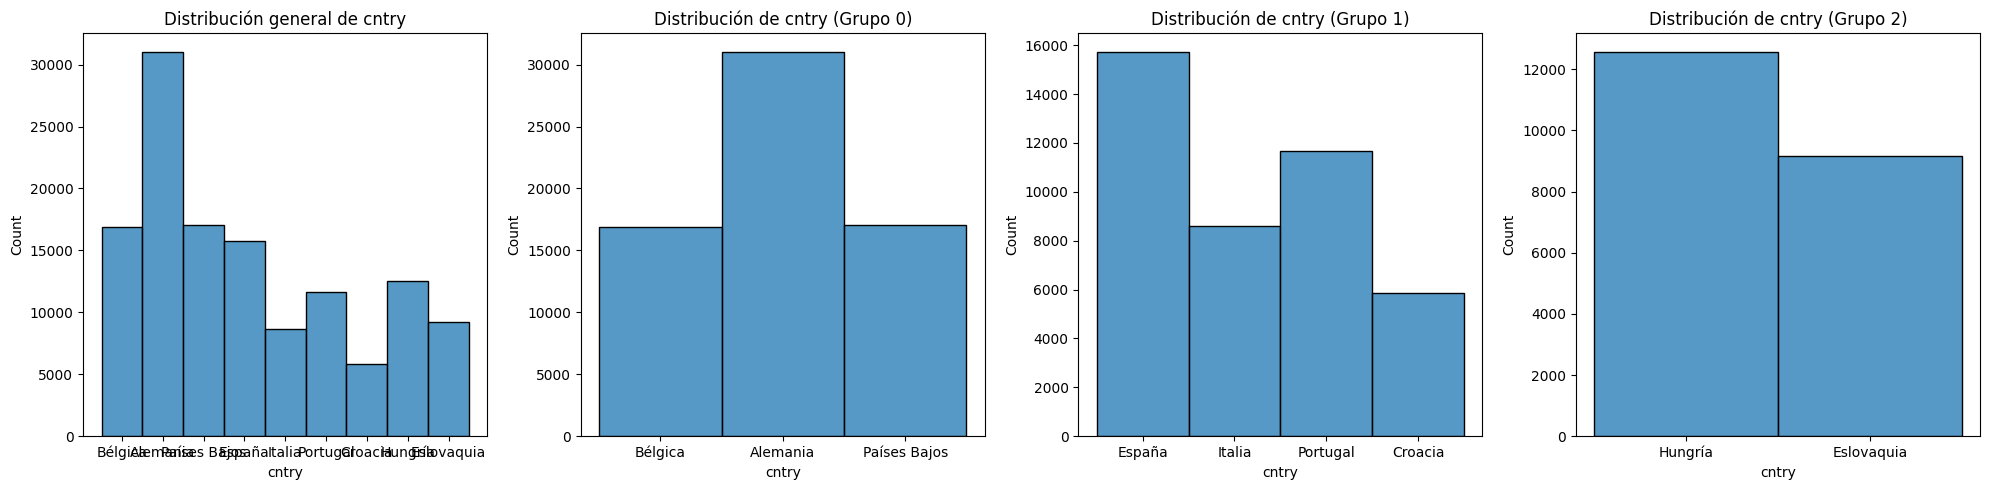

In [ ]:
#Vamos a observar la columna cntry para ver la cantidad de muestras de cada pais.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def dist4(df, columna, grupo_columna='cntgrp_fc'):


    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    
    sns.histplot(df[columna], ax=axes[0])
    axes[0].set_title(f'Distribución general de {columna}')

   
    sns.histplot(df[df[grupo_columna] == 0][columna], ax=axes[1])
    axes[1].set_title(f'Distribución de {columna} (Grupo 0)')

    
    sns.histplot(df[df[grupo_columna] == 1][columna], ax=axes[2])
    axes[2].set_title(f'Distribución de {columna} (Grupo 1)')

    
    sns.histplot(df[df[grupo_columna] == 2][columna], ax=axes[3])
    axes[3].set_title(f'Distribución de {columna} (Grupo 2)')

    plt.tight_layout()
    plt.show()


dist4(dfeu, 'cntry')

Como podemos observar en la variable paises, hay un desbalanceo de clases, hay muchas mas muestras de alemania que del resto. Habra que tenerlo en cuenta a la hora de realizar el modelo de clasificacion.
Si el objetivo es ver la naturaleza de las distribuciones y obtener las principales variables estadisticas, un desbalance en las clases de este calibre, nos influira negativamente en el analisis de las distribuciones,
si nos interesa ver como influye cada grupo logico de muestras
.

En este documento se analizaran las principales variables estadisticas de cada columna.
Ademas de hacer una breve descripcion del tipo de funcion que describe la distribucion y un analisis breve de lo que ello significa.
'count': 'Número de muestras sin valores nulos',
'mean': 'Media aritmética',
'std': 'Desviación estándar, nos da una idea de cuanto se alejan los rangos de las muestras respecto a la media aritmetica, con un numero mas grande significa que mas varia',
'min': 'Valor mínimo, el valor minimo',
'25%': 'Percentil 25', el valor del rango de la variable donde se alojan el primer 25% de las muestras, ,
'50%': 'Mediana (percentil 50)', es el valor de la variable donde se divide el 50% de los datos,
'75%': 'Percentil 75', es el valor de la variable donde se ecuentran 3/4 de las muestras totales,
'max': 'Valor máximo', es el valor maximo de la variable que alcanza en el conjunto de las muestras,
'unique': 'Número de valores únicos',
'top': 'Valor más frecuente',
'freq': 'Frecuencia del valor más frecuente'

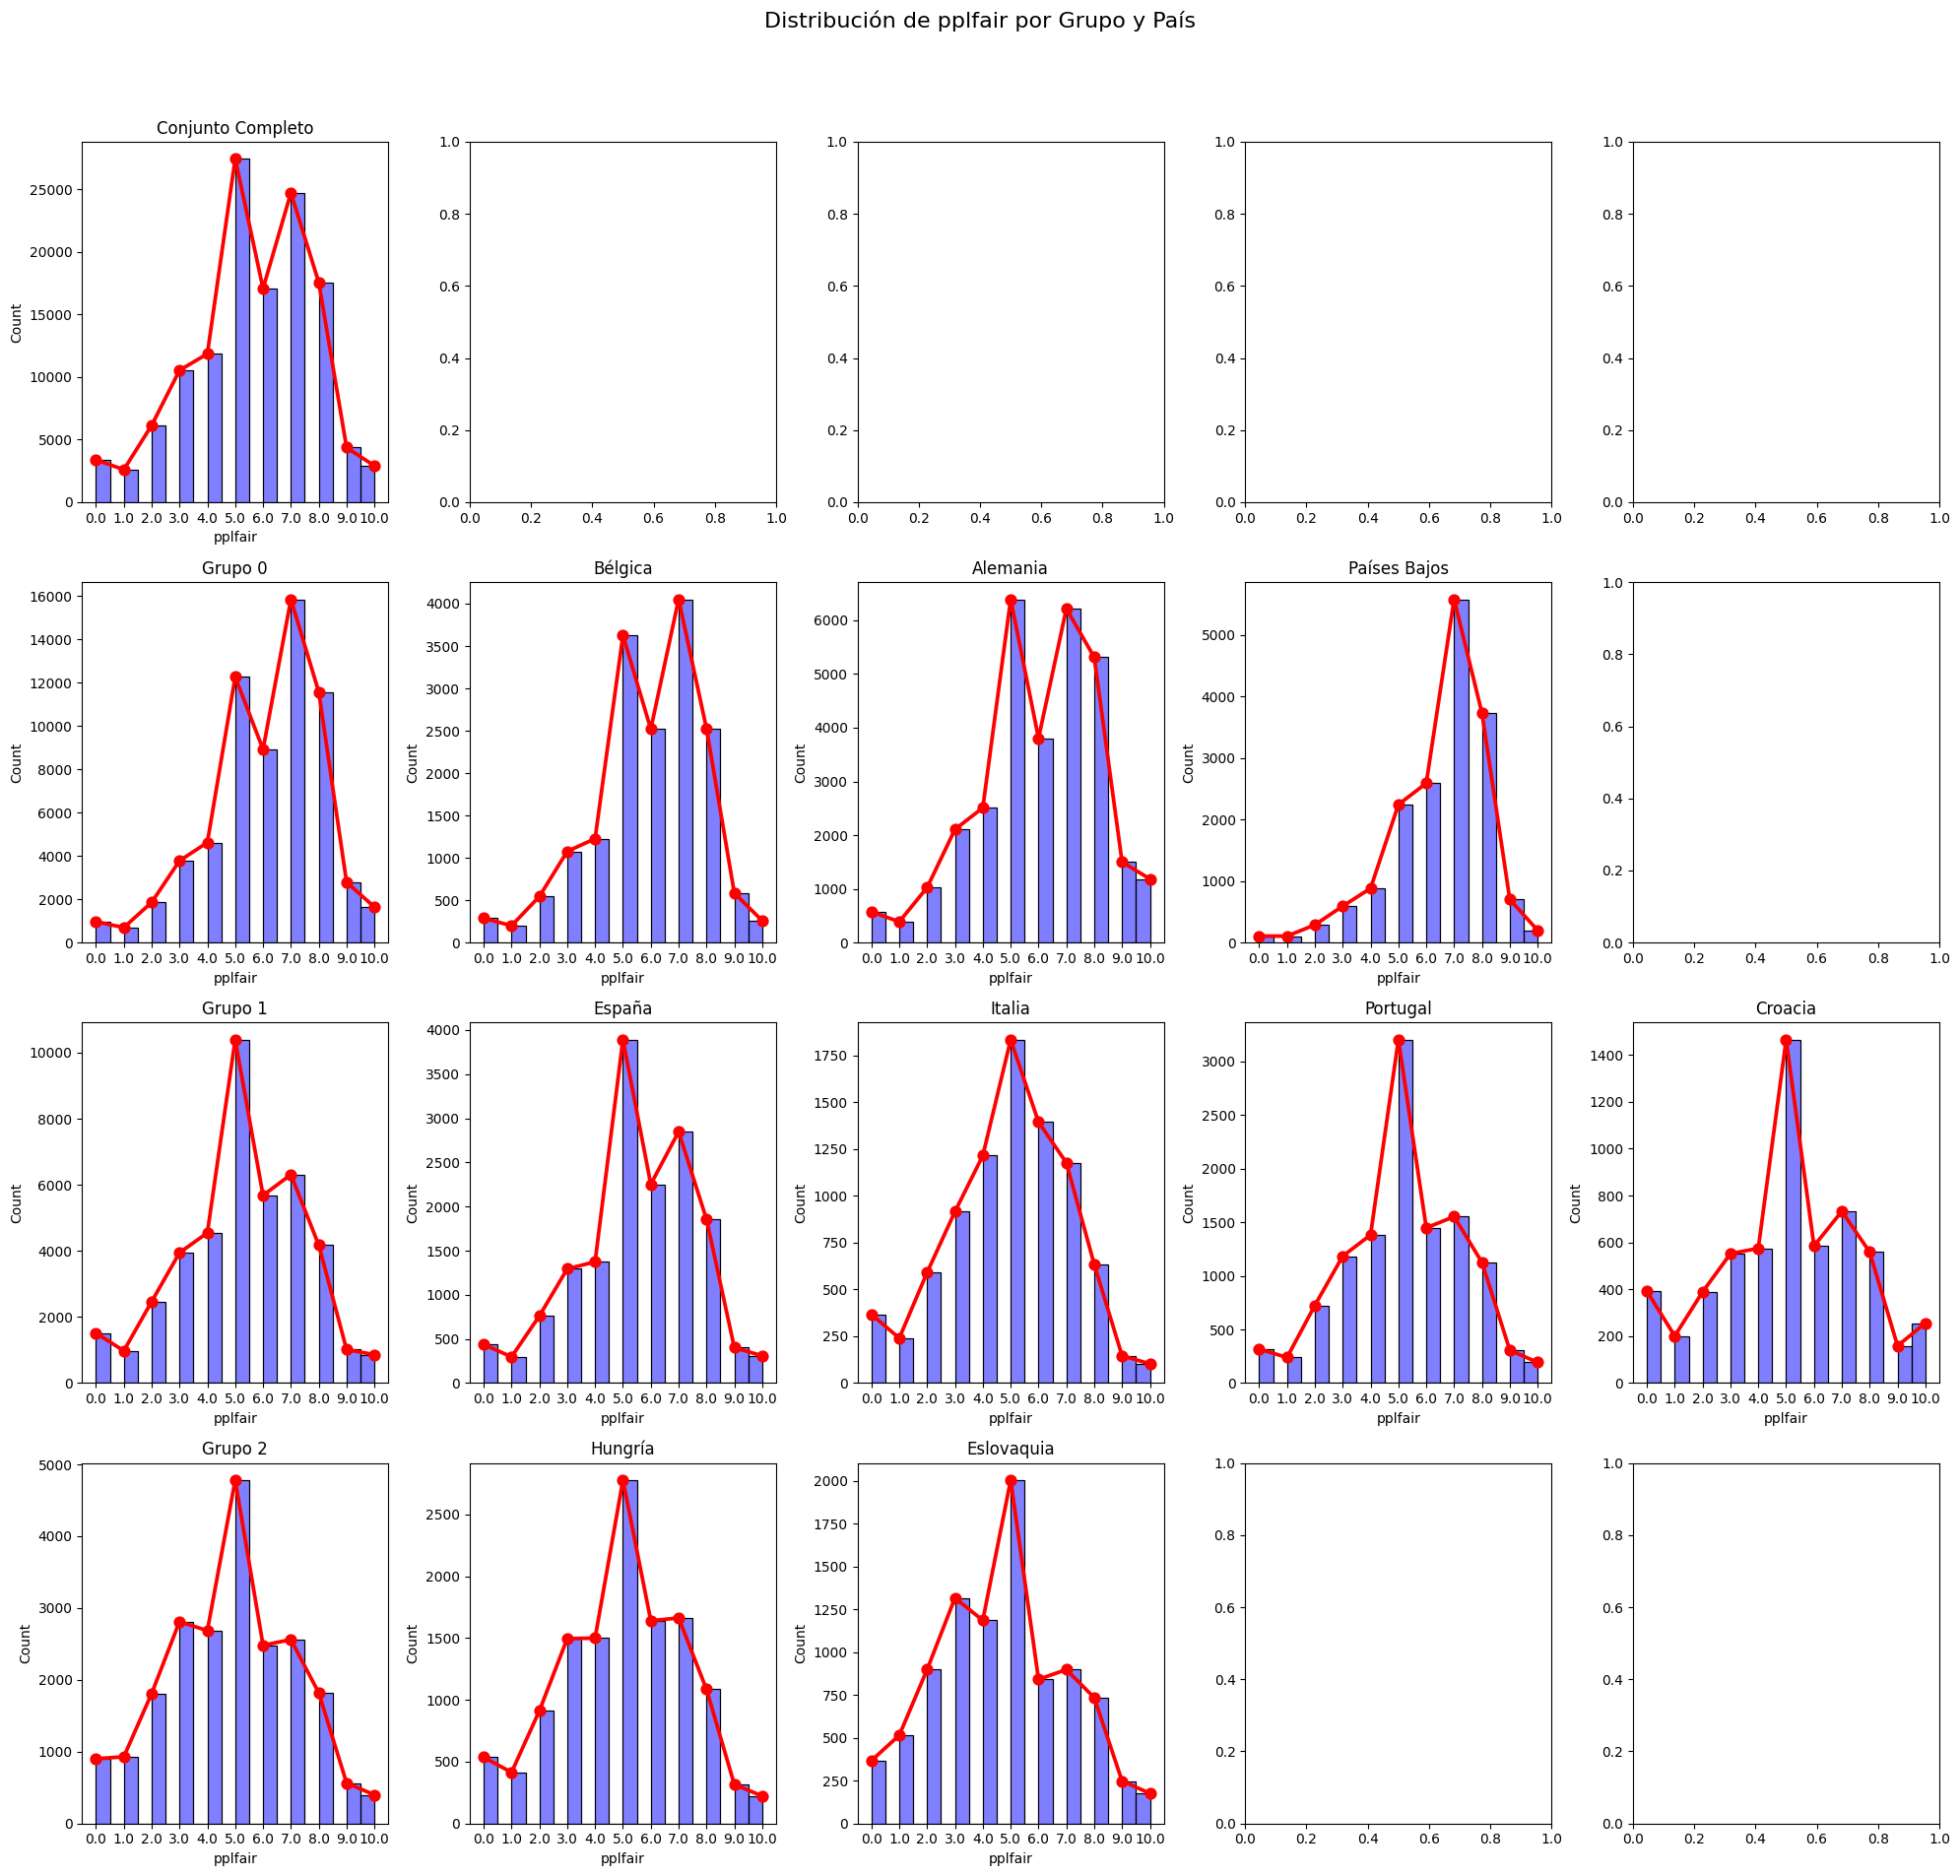

In [ ]:
#Para la variable 'pplfair'
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def GroupDist(dataset, columna_a_graficar):


    
    grupos = dataset['cntgrp_fc'].unique()

    
    max_paises = max(dataset.groupby('cntgrp_fc')['cntry'].nunique())

    
    fig, axes = plt.subplots(len(grupos) + 1, max_paises + 1, figsize=(20, 5 * (len(grupos) + 1)))
    fig.suptitle(f'Distribución de {columna_a_graficar} por Grupo y País', fontsize=16)

    
    sns.histplot(dataset[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[0, 0])
    sns.pointplot(x=dataset[columna_a_graficar].value_counts().sort_index().index,
                  y=dataset[columna_a_graficar].value_counts().sort_index().values,
                  color='red', linestyles='-', ax=axes[0, 0])
    axes[0, 0].set_title('Conjunto Completo')

    
    for i, grupo in enumerate(grupos):
        datos_grupo = dataset[dataset['cntgrp_fc'] == grupo]
        sns.histplot(datos_grupo[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[i + 1, 0])
        sns.pointplot(x=datos_grupo[columna_a_graficar].value_counts().sort_index().index,
                      y=datos_grupo[columna_a_graficar].value_counts().sort_index().values,
                      color='red', linestyles='-', ax=axes[i + 1, 0])
        axes[i + 1, 0].set_title(f'Grupo {grupo}')

        
        paises = dataset[dataset['cntgrp_fc'] == grupo]['cntry'].unique()
        for j, pais in enumerate(paises):
            datos_pais = dataset[(dataset['cntgrp_fc'] == grupo) & (dataset['cntry'] == pais)]
            sns.histplot(datos_pais[columna_a_graficar], color='blue', alpha=0.5, binwidth=0.5, ax=axes[i + 1, j + 1])
            sns.pointplot(x=datos_pais[columna_a_graficar].value_counts().sort_index().index,
                          y=datos_pais[columna_a_graficar].value_counts().sort_index().values,
                          color='red', linestyles='-', ax=axes[i + 1, j + 1])
            axes[i + 1, j + 1].set_title(pais)

    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

GroupDist(dfeu, 'pplfair')

In [ ]:
import pandas as pd

def statsgroup(dataset, columna_a_analizar):

    def calcular_varianza(columna):
        return columna.var()
    def calcular_moda_frecuencia(columna):
        moda = columna.mode()
        if not moda.empty:
            frecuencia = columna.value_counts()[moda.iloc[0]]
            return moda.iloc[0], frecuencia
        else:
            return None, None
    print(f"Estadísticas para {columna_a_analizar} - Conjunto Completo:")
    print(dataset[columna_a_analizar].describe())
    moda, frecuencia = calcular_moda_frecuencia(dataset[columna_a_analizar])
    print(f"Moda: {moda}, Frecuencia: {frecuencia}")
    print(f"Varianza: {calcular_varianza(dataset[columna_a_analizar])}")
    print("\n")

    
    grupos = dataset['cntgrp_fc'].unique()
    for grupo in grupos:
        datos_grupo = dataset[dataset['cntgrp_fc'] == grupo]
        print(f"Estadísticas para {columna_a_analizar} - Grupo {grupo}:")
        print(datos_grupo[columna_a_analizar].describe())
        moda, frecuencia = calcular_moda_frecuencia(datos_grupo[columna_a_analizar])
        print(f"Moda: {moda}, Frecuencia: {frecuencia}")
        print(f"Varianza: {calcular_varianza(datos_grupo[columna_a_analizar])}")
        print("\n")

        
        paises = dataset[dataset['cntgrp_fc'] == grupo]['cntry'].unique()
        for pais in paises:
            datos_pais = dataset[(dataset['cntgrp_fc'] == grupo) & (dataset['cntry'] == pais)]
            print(f"Estadísticas para {columna_a_analizar} - País {pais} (Grupo {grupo}):")
            print(datos_pais[columna_a_analizar].describe())
            moda, frecuencia = calcular_moda_frecuencia(datos_pais[columna_a_analizar])
            print(f"Moda: {moda}, Frecuencia: {frecuencia}")
            print(f"Varianza: {calcular_varianza(datos_pais[columna_a_analizar])}")
            print("\n")


statsgroup(dfeu, 'pplfair')

Estadísticas para pplfair - Conjunto Completo:
count    128563.000000
mean          5.563871
std           2.180197
min           0.000000
25%           4.000000
50%           6.000000
75%           7.000000
max          10.000000
Name: pplfair, dtype: float64
Moda: 5.0, Frecuencia: 27432
Varianza: 4.753257338265889


Estadísticas para pplfair - Grupo 0:
count    64935.000000
mean         6.066913
std          2.001033
min          0.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: pplfair, dtype: float64
Moda: 7.0, Frecuencia: 15843
Varianza: 4.004131313707191


Estadísticas para pplfair - País Bélgica (Grupo 0):
count    16906.000000
mean         5.862652
std          1.969376
min          0.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         10.000000
Name: pplfair, dtype: float64
Moda: 7.0, Frecuencia: 4052
Varianza: 3.878442985524672


Estadísticas para pplfair - País Alemania (Grupo 0):
count    

Para nuestra variable/columna 'pplfair':
(2-'pplfair': Escala 0 a 10. 0 si crees que la gente intenta aprovecharse, a 10 si crees que la gente es honesta.)
Es una variable discontinua que sigue una distribucion normal simetrica bimodal.
Es decir que la mayor cantidad de muestras se dividen en dos montones claramente visibles y en este caso en particular bastante centrados.
Si observamos esta variable en los conjuntos de paises, conforme los paises son mas pobres, la media aritmetica
va coincidiendo con la moda, por lo que graficamente solo se observa un maximo local y desaparece el segundo.
Tambien se aprecia una disminucion de la varianza.
De momento nuestra hipotesis de que la situacion economica influye en las variables es probable, los dibujos por grupos de paises coinciden bastante con los de paises individualmente.

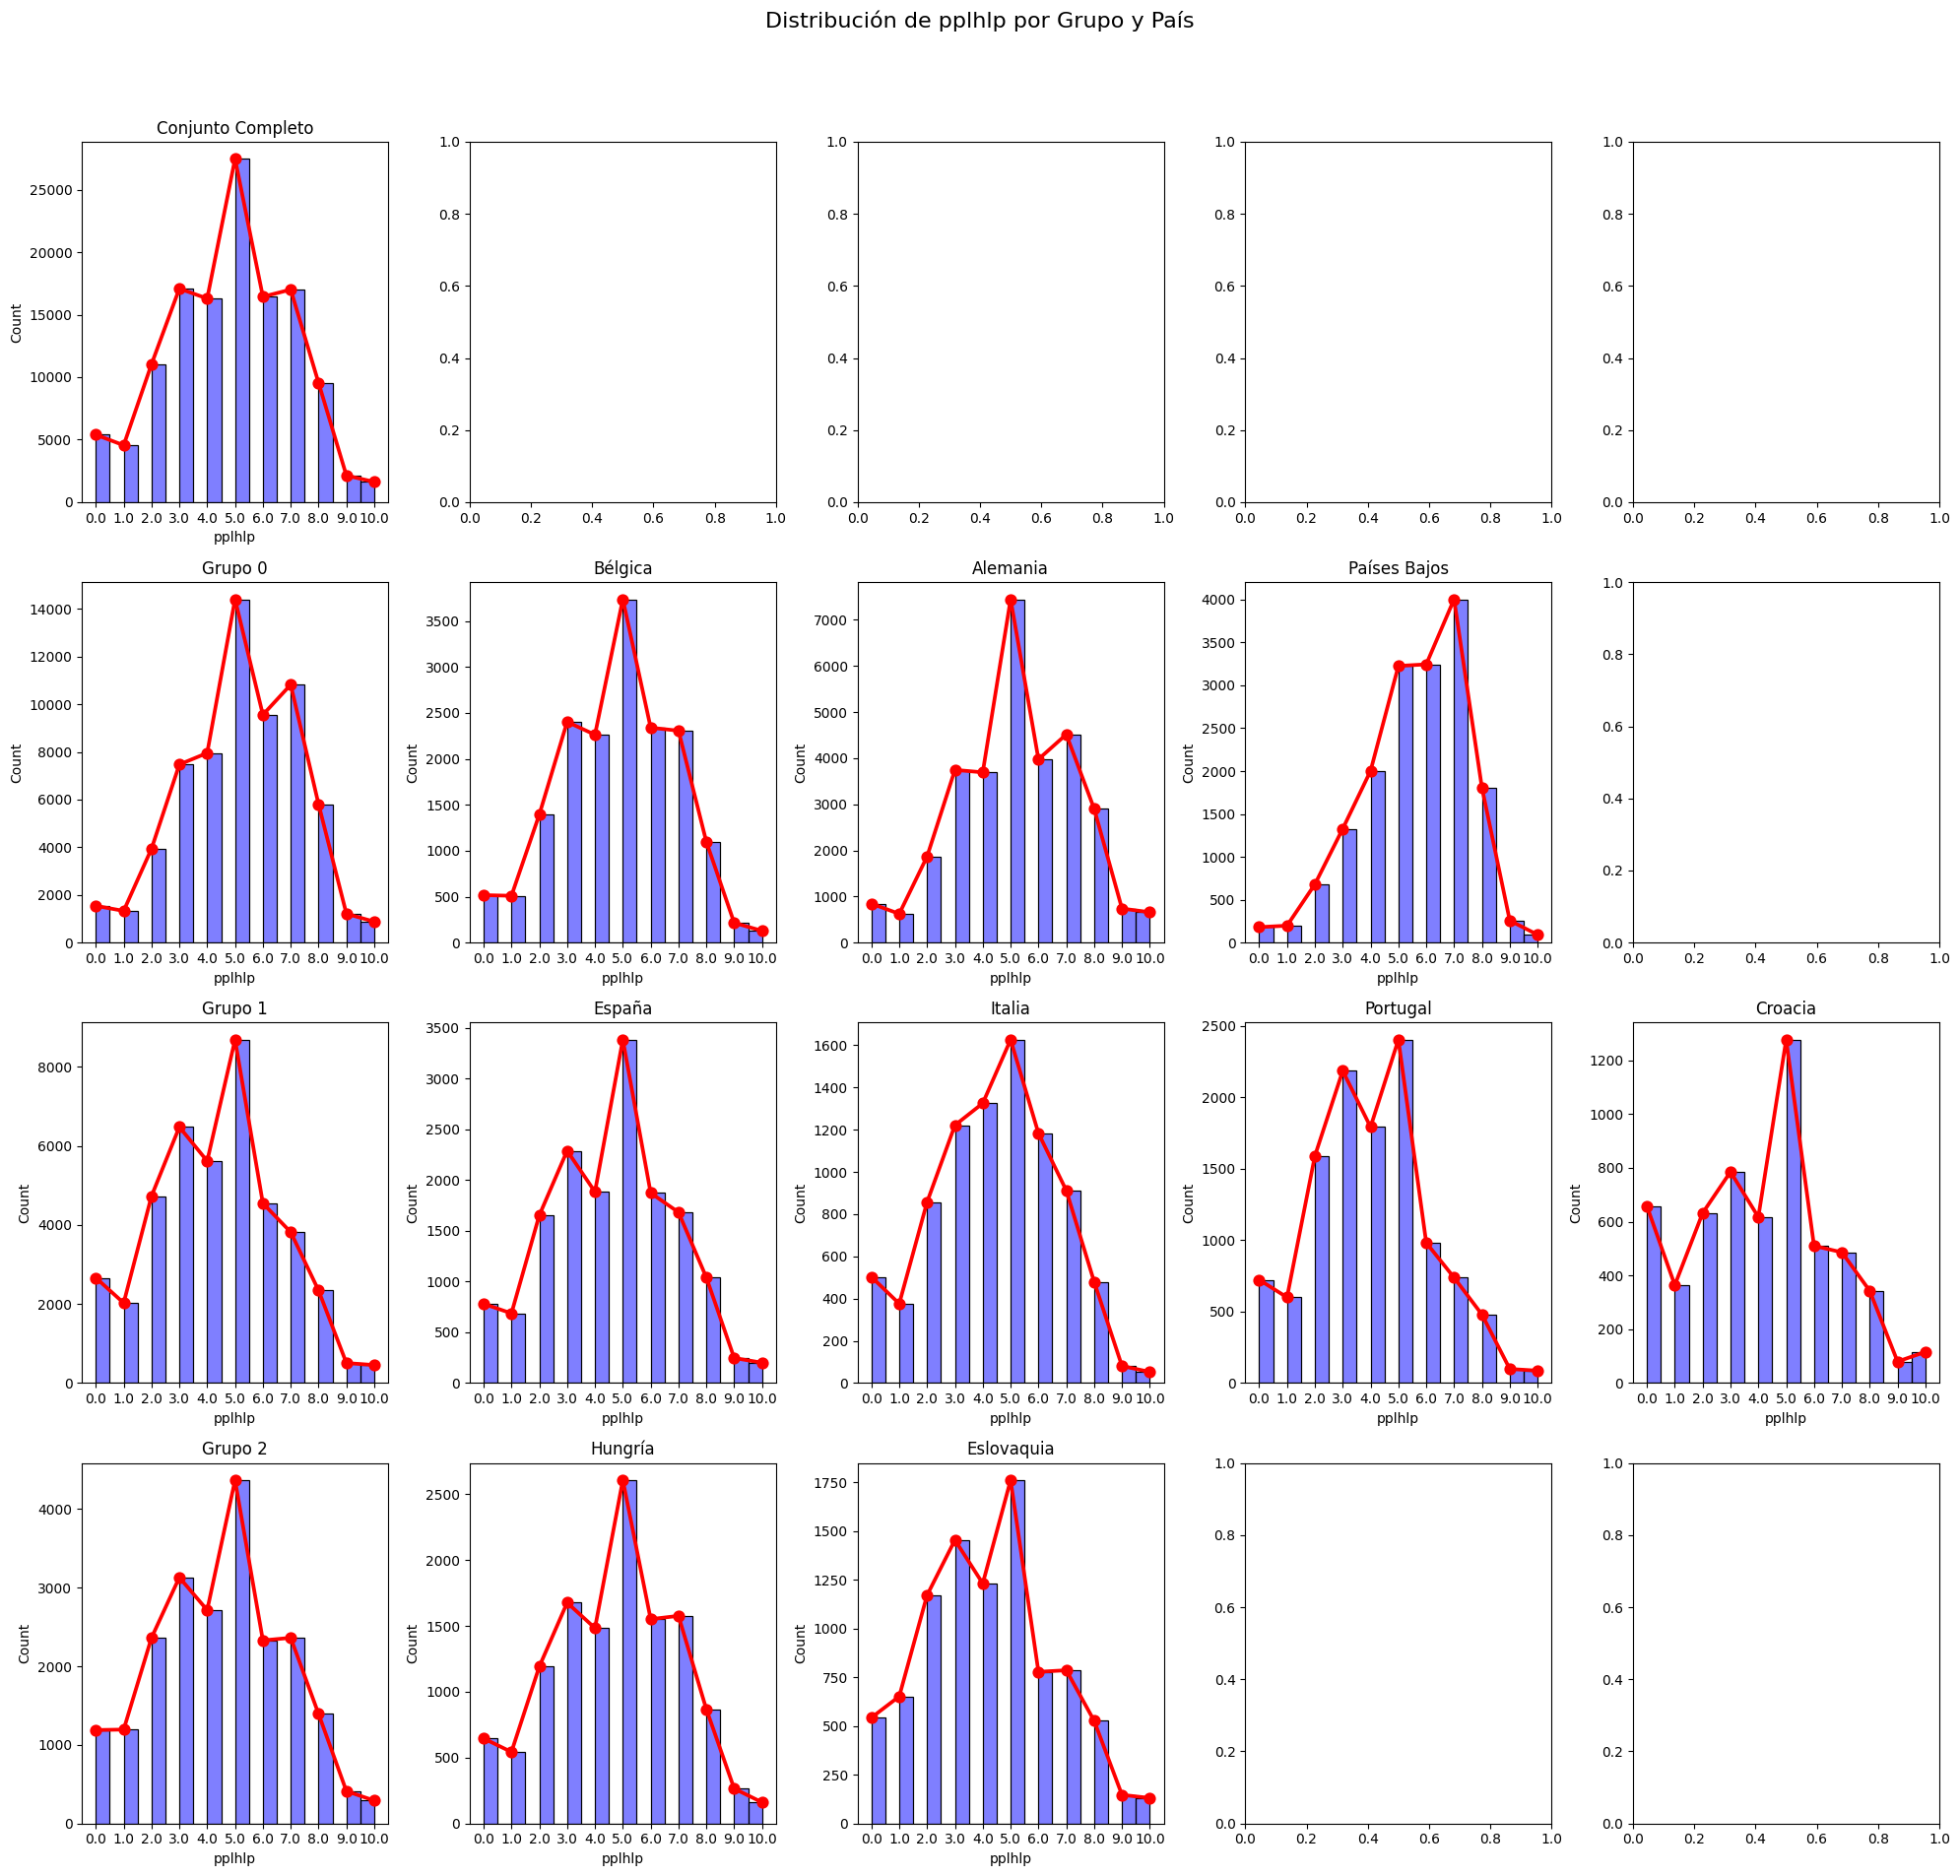

Estadísticas para pplhlp - Conjunto Completo:
count    128563.000000
mean          4.743239
std           2.210941
min           0.000000
25%           3.000000
50%           5.000000
75%           6.000000
max          10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 27461
Varianza: 4.888258663215718


Estadísticas para pplhlp - Grupo 0:
count    64935.000000
mean         5.155586
std          2.069864
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 14406
Varianza: 4.284336573282272


Estadísticas para pplhlp - País Bélgica (Grupo 0):
count    16906.000000
mean         4.756122
std          2.072160
min          0.000000
25%          3.000000
50%          5.000000
75%          6.000000
max         10.000000
Name: pplhlp, dtype: float64
Moda: 5.0, Frecuencia: 3736
Varianza: 4.293847463118177


Estadísticas para pplhlp - País Alemania (Grupo 0):
count    31012.0

In [20]:
#Para la variable 'pplhlp'
GroupDist(dfeu, 'pplhlp')
statsgroup(dfeu, 'pplhlp')

Para la variable 'pplhlp':
(3-'pplhlp': Escala 0 a 10. 0 si crees que la gente solo miran por sus intereses, a 10 si crees que la gente mira por el bien comun.)

Variable discontinua que  funcion normal simetrica, si que es cierto que conforme, el grupo de paises es mas pobre
Tiene a bimodalizarse.
Se observa una ligera asimetria hacia un valor de rango positivo en el caso de las muestras de Paises Bajos.
Quiza su escasa poblacion o por cuestiones culturales, la gente tiende a pensar que la gente mira por el bien comun.
La variable con el conjunto total de muestras tiende a asemejarse a la distribucion Alemana, a parte de porque es el conjunto
con mas muestras tambien es porque casi todos los paises tienen distribuciones parejas.
El criterio de agrupacion sigue cumpliendose con apenas diferencias en las distribuciones del grupo y sus paises.

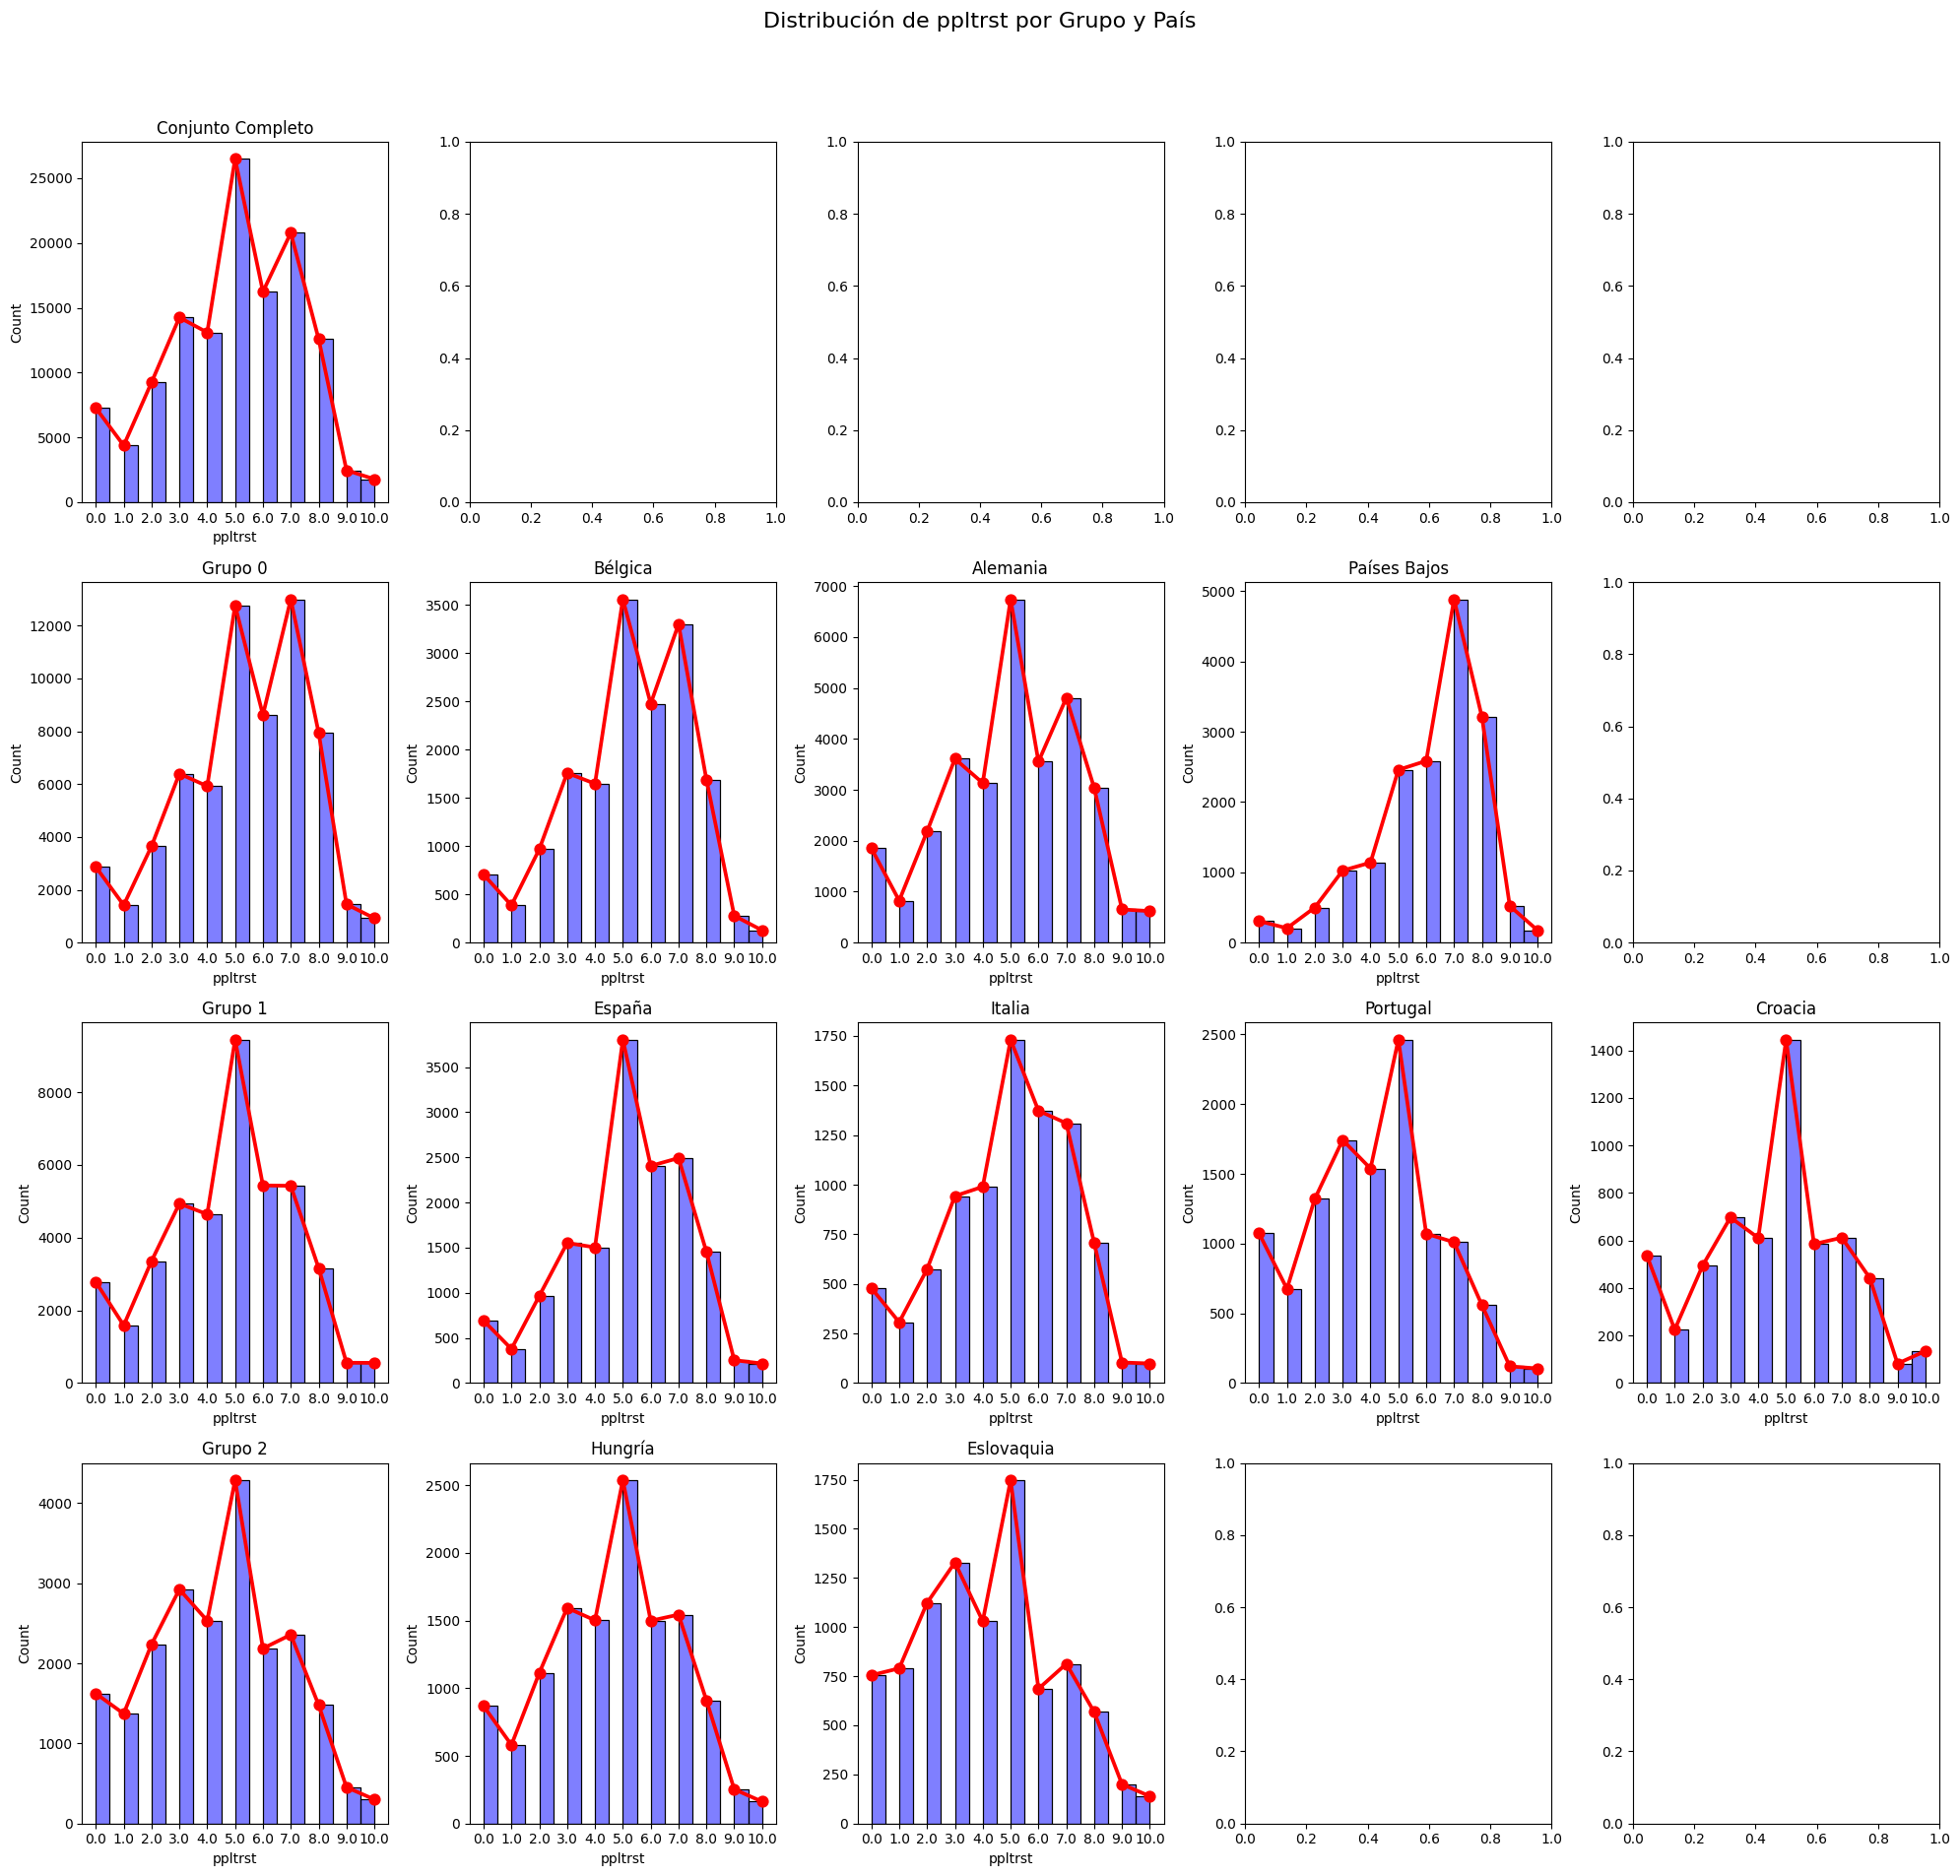

In [22]:
GroupDist(dfeu, 'ppltrst')

In [23]:
statsgroup(dfeu, 'ppltrst')

Estadísticas para ppltrst - Conjunto Completo:
count    128563.000000
mean          4.931007
std           2.335035
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          10.000000
Name: ppltrst, dtype: float64
Moda: 5.0, Frecuencia: 26488
Varianza: 5.452388951925295


Estadísticas para ppltrst - Grupo 0:
count    64935.000000
mean         5.295557
std          2.259137
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: ppltrst, dtype: float64
Moda: 7.0, Frecuencia: 12993
Varianza: 5.1037001913029885


Estadísticas para ppltrst - País Bélgica (Grupo 0):
count    16906.000000
mean         5.163196
std          2.166737
min          0.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: ppltrst, dtype: float64
Moda: 5.0, Frecuencia: 3560
Varianza: 4.694749533347099


Estadísticas para ppltrst - País Alemania (Grupo 0):
count   

4-'ppltrst': Escala de 0 a 10. 0 Si crees que no puedes confiar en nadie, a 10 si crees que se puede confiar.
Variable discontinua que describe a primera vista una funcion normal simetrica bimodal, escepto en el grupo dos donde casi se asemeja
a su media aritmetica.
En el primer grupo tiende a bimodalizarse a partir de rangos mayores a la media aritmetica por lo que sugiere que conforme, las condiciones economicas son mejores, la gente suele confiar mas.
En el segundo grupo se aprecian discrepancias entre las muestras de los distintos paises, aun asi se asemejan al grafico de muestras
de su grupo.
En el  tercer grupo se puede apreciar incluso una funcion normal simetrica trimodal, con ambos dos subconjuntos alrededor del valor, tanto por arriba como por abajo de la media aritmetica de la variable.
Bastante bien distribuido, en todo el rango de la variable.
En el conjunto global de datos de esta variable, casi se describe una distribucion simetrica trimodal.
Por lo general las distribuciones entre paises y sus grupos se asemejan bastante.


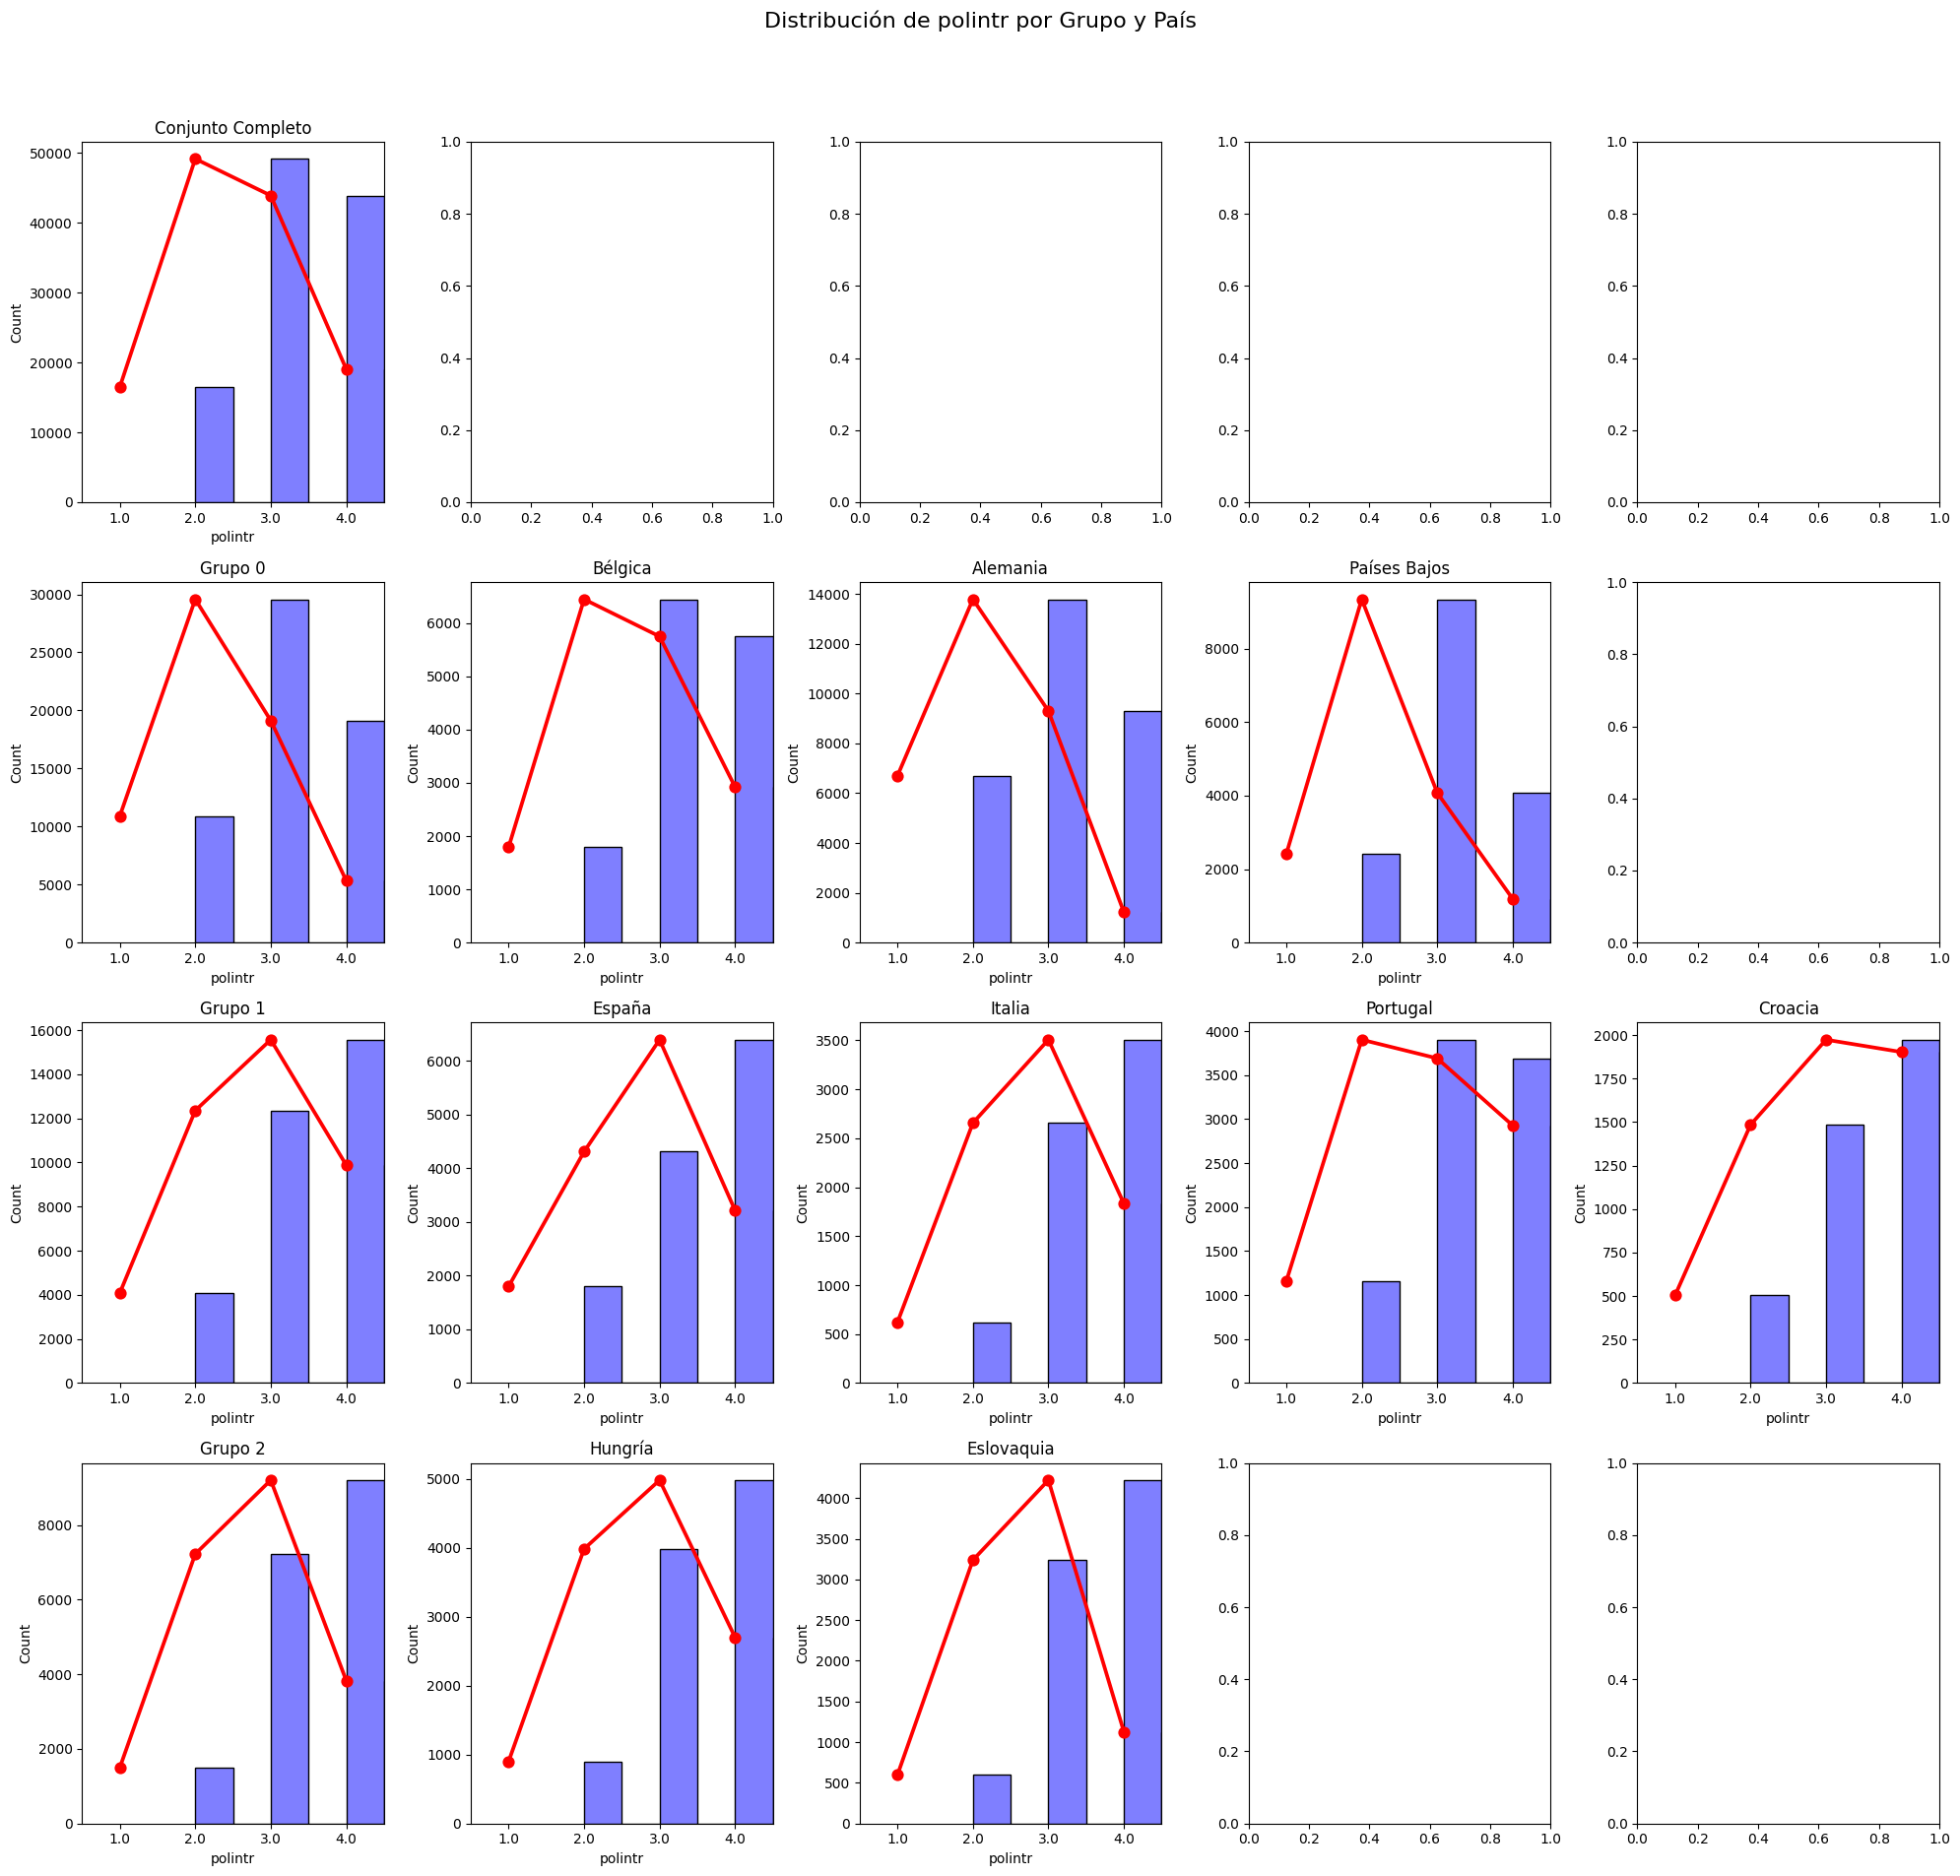

In [24]:
#Variable 'polintr'
GroupDist(dfeu, 'polintr')

In [26]:
statsgroup(dfeu, 'polintr')

Estadísticas para polintr - Conjunto Completo:
count    128563.000000
mean          2.509532
std           0.895746
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max           4.000000
Name: polintr, dtype: float64
Moda: 2.0, Frecuencia: 49155
Varianza: 0.8023604811428849


Estadísticas para polintr - Grupo 0:
count    64935.000000
mean         2.291076
std          0.840366
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: polintr, dtype: float64
Moda: 2.0, Frecuencia: 29578
Varianza: 0.7062152087192899


Estadísticas para polintr - País Bélgica (Grupo 0):
count    16906.000000
mean         2.579617
std          0.895199
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          4.000000
Name: polintr, dtype: float64
Moda: 2.0, Frecuencia: 6445
Varianza: 0.8013804150395004


Estadísticas para polintr - País Alemania (Grupo 0):
count 

5-'polintr': Escala de 1 a 4 de intensidad. 1 muy interesado en politica, a 4 estando nada interesado.
Variable discontinua con 5 posibles valores, su distribucion sigue una funcion normal con un detalle interesante a comentar.
Conforme vamos mirando los graficos por grupos de paises podemos observar tanto en las graficas como en los datos de moda y media aritmetica, conforme los grupos son de paises mas pobres , el interes por politica se va perdiendo.
Es decir la media aritmetica cercana a 2 del grupo 0(rico), se va desplazando hasta casi alcanzar el 3 en el grupo 2.
Por el desbalance de clases(hay muchas mas muestras del grupo 0 al resto) agrupando por grupos de paises,
La distribucion general se centra en el valor medio aritmetico de la variable discontinua.
